In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Load the dataset
file_path = r'C:/xampp/htdocs/cyber_security/static/cybersecurity_attacks.csv'

df = pd.read_csv(file_path)

print("Dataset loaded successfully. Displaying the first 5 rows:")
print(df.head())

Dataset loaded successfully. Displaying the first 5 rows:
             Timestamp Source IP Address Destination IP Address  Source Port  \
0  2023-05-30 06:33:58     103.216.15.12           84.9.164.252        31225   
1  2020-08-26 07:08:30    78.199.217.198         66.191.137.154        17245   
2  2022-11-13 08:23:25      63.79.210.48          198.219.82.17        16811   
3  2023-07-02 10:38:46     163.42.196.10        101.228.192.255        20018   
4  2023-07-16 13:11:07     71.166.185.76        189.243.174.238         6131   

   Destination Port Protocol  Packet Length Packet Type Traffic Type  \
0             17616     ICMP            503        Data         HTTP   
1             48166     ICMP           1174        Data         HTTP   
2             53600      UDP            306     Control         HTTP   
3             32534      UDP            385        Data         HTTP   
4             26646      TCP           1462        Data          DNS   

                            

In [14]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [20]:
print("Dataset information:")
df.info()

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               40000 non-null  str    
 1   Source IP Address       40000 non-null  str    
 2   Destination IP Address  40000 non-null  str    
 3   Source Port             40000 non-null  int64  
 4   Destination Port        40000 non-null  int64  
 5   Protocol                40000 non-null  str    
 6   Packet Length           40000 non-null  int64  
 7   Packet Type             40000 non-null  str    
 8   Traffic Type            40000 non-null  str    
 9   Payload Data            40000 non-null  str    
 10  Malware Indicators      20000 non-null  str    
 11  Anomaly Scores          40000 non-null  float64
 12  Alerts/Warnings         19933 non-null  str    
 13  Attack Type             40000 non-null  str    
 14  Attack Signature        4000

In [21]:
print("Descriptive statistics for numerical columns:")
display(df.describe())

Descriptive statistics for numerical columns:


,Source Port,Destination Port,Packet Length,Anomaly Scores
count,40000.000000,40000.000000,40000.000000,40000.000000
mean,32970.356450,33150.868650,781.452725,50.113473
std,18560.425604,18574.668842,416.044192,28.853598
min,1027.000000,1024.000000,64.000000,0.000000
25%,16850.750000,17094.750000,420.000000,25.150000
50%,32856.000000,33004.500000,782.000000,50.345000
75%,48928.250000,49287.000000,1143.000000,75.030000
max,65530.000000,65535.000000,1500.000000,100.000000


EDA(Exploration Data Analysis)


**CEK MISSING DATA**



Checking Missing Values...


,Missing Count,Missing Percentage (%)
Alerts/Warnings,20067,50.1675
IDS/IPS Alerts,20050,50.1250
Malware Indicators,20000,50.0000
Firewall Logs,19961,49.9025
Proxy Information,19851,49.6275


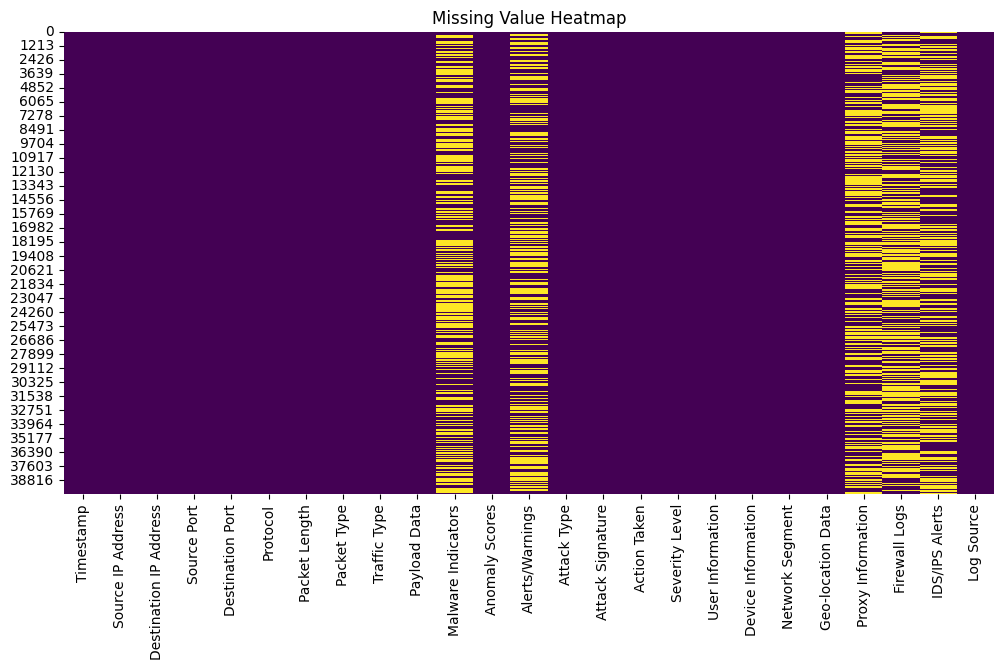

In [22]:
print("\nChecking Missing Values...")

missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage (%)': missing_percentage
})

missing_df = missing_df[missing_df['Missing Count'] > 0]

if len(missing_df) > 0:
    display(missing_df.sort_values(by='Missing Count', ascending=False))
else:
    print("Tidak ada missing values.")

# Visualisasi Missing Value
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Value Heatmap")
plt.show()

**CEK DUPLICATE DATA**


In [23]:
print("\nChecking Duplicate Data...")

duplicate = df.duplicated().sum()

print(f"Jumlah Duplicate Data: {duplicate}")

# Hapus duplicate jika diperlukan
df = df.drop_duplicates()

print("\nUkuran Dataset Setelah Hapus Duplicate:")
print(df.shape)


Checking Duplicate Data...
Jumlah Duplicate Data: 0

Ukuran Dataset Setelah Hapus Duplicate:
(40000, 25)


**CEK DISTRIBUSI TARGET**



Distribusi Target (Attack Type):


,count
Attack Type,
DDoS,13428
Malware,13307
Intrusion,13265


/tmp/ipykernel_1023/1484893095.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Attack Type', palette='viridis')


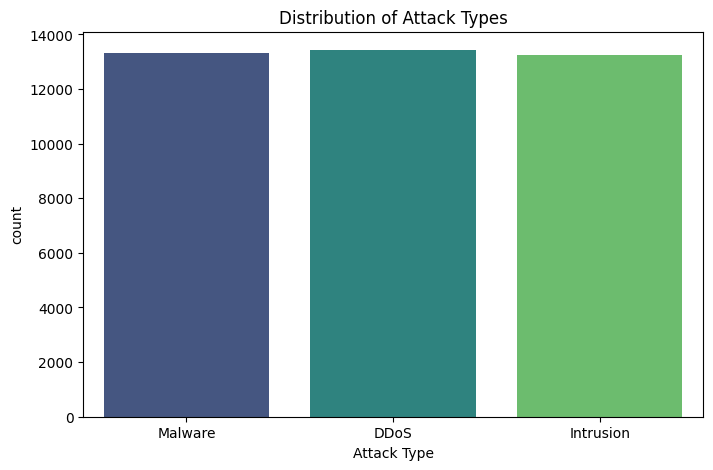

In [ ]:
print("\nDistribusi Target (Attack Type):")
display(df['Attack Type'].value_counts())

# Visualisasi Distribusi Target
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Attack Type', palette='viridis')

plt.title('Distribution of Attack Types')
plt.show()

**DATA VISUALIZATION**

TRAFFIC TYPE

C:\Users\Catrinee\AppData\Local\Temp\ipykernel_18436\953269271.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Traffic Type', palette='Set2')


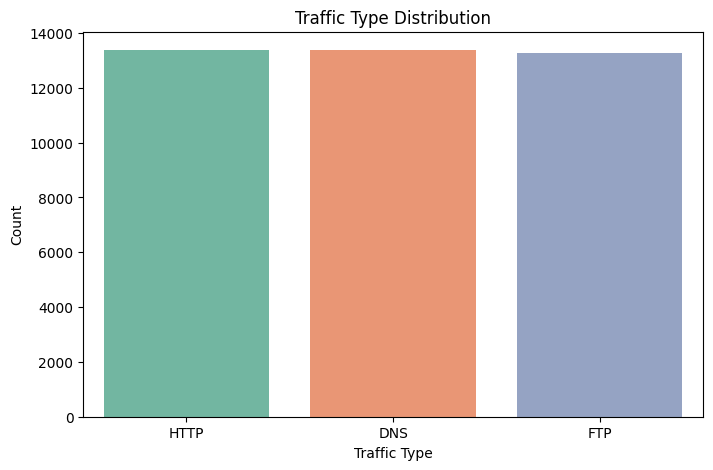

In [24]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Traffic Type', palette='Set2')

plt.title('Traffic Type Distribution')
plt.xlabel('Traffic Type')
plt.ylabel('Count')

plt.show()

PROTOCOL


C:\Users\Catrinee\AppData\Local\Temp\ipykernel_18436\3046605560.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Protocol', palette='coolwarm')


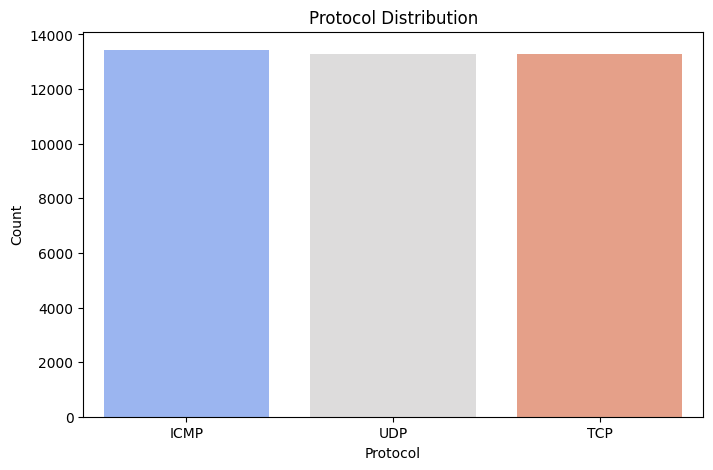

In [25]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Protocol', palette='coolwarm')

plt.title('Protocol Distribution')
plt.xlabel('Protocol')
plt.ylabel('Count')

plt.show()

SEVERITY LEVEL


C:\Users\Catrinee\AppData\Local\Temp\ipykernel_18436\3131588840.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Severity Level', palette='magma')


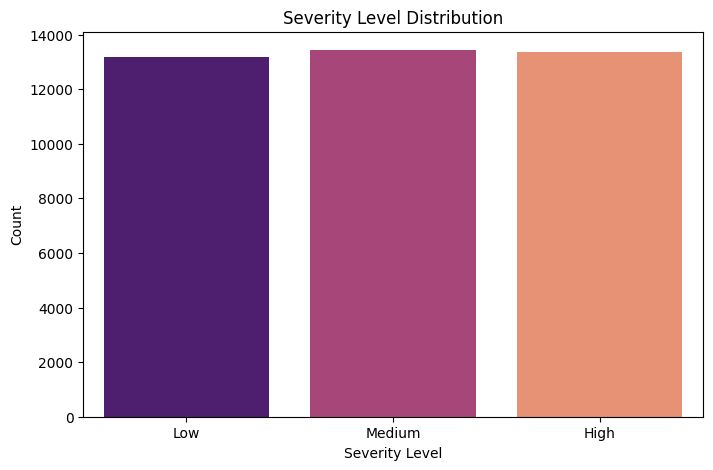

In [26]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Severity Level', palette='magma')

plt.title('Severity Level Distribution')
plt.xlabel('Severity Level')
plt.ylabel('Count')

plt.show()

CORRELATION


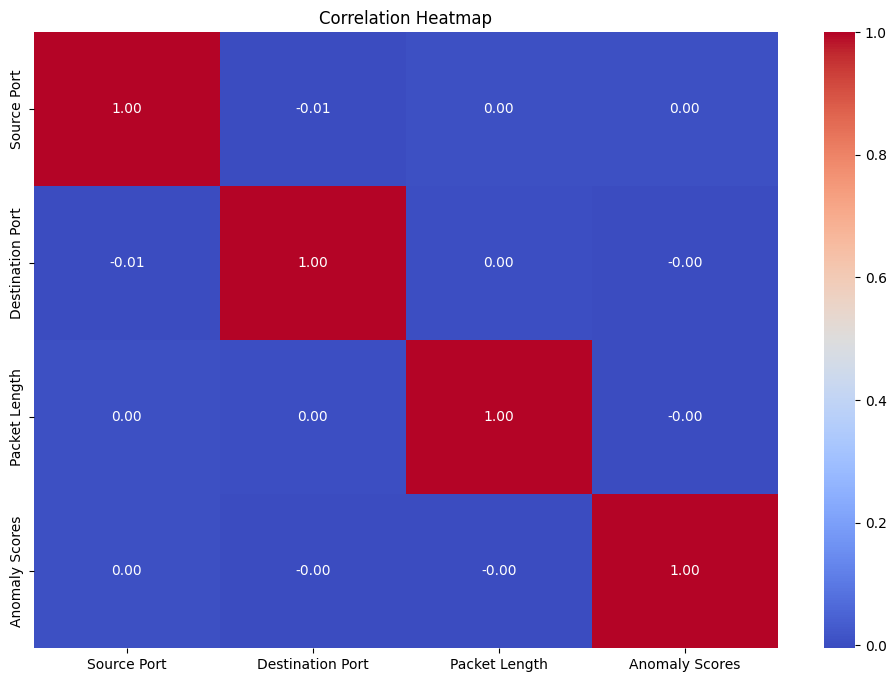

In [27]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()


HISTOGRAM


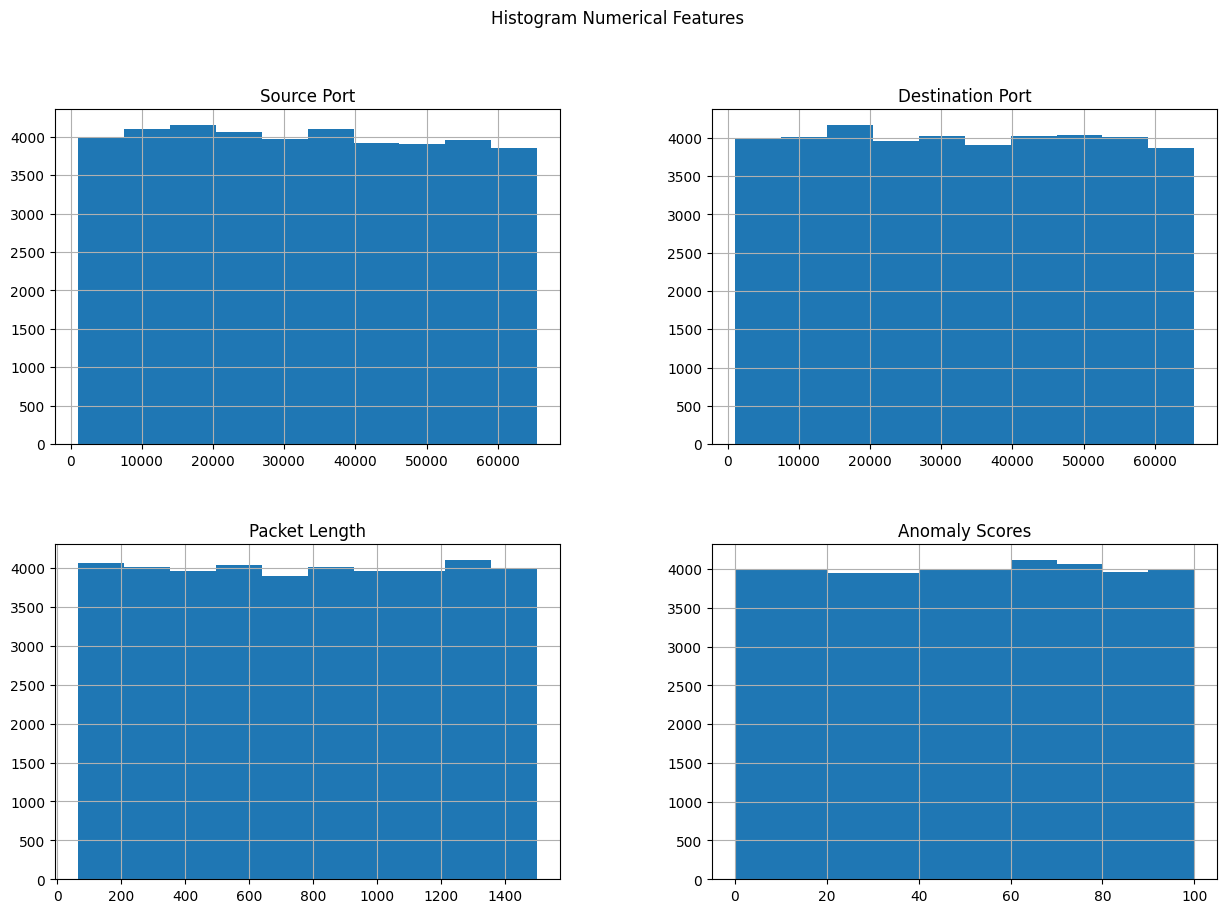

In [28]:
numeric_df.hist(figsize=(15,10))
plt.suptitle("Histogram Numerical Features")
plt.show()

**DATA PREPROCESSING**

In [29]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [30]:
import pandas as pd
import numpy as np
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

# Download resource NLTK
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Catrinee\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Catrinee\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Catrinee\AppData\Roaming\nltk_data...


True

PILIH KOLOM TEKS


In [31]:
text_column = 'Timestamp', 'Source IP Address', 'Source Port', 'Destination Port', 'Protocol', 'Packet Length', 'Packet Type', 'Traffic Type', 'Payload Data', 'Malware Indicators', 'Anomaly Scores', 'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken', 'Severity Level', 'User Information', 'Device Information', 'Network Segment', 'Geo-location Data', 'Proxy Information', 'Firewall Logs', 'IDS/IPS Alerts', 'Log Source'

In [32]:
print(df[list(text_column)].head())

             Timestamp Source IP Address  Source Port  Destination Port  \
0  2023-05-30 06:33:58     103.216.15.12        31225             17616   
1  2020-08-26 07:08:30    78.199.217.198        17245             48166   
2  2022-11-13 08:23:25      63.79.210.48        16811             53600   
3  2023-07-02 10:38:46     163.42.196.10        20018             32534   
4  2023-07-16 13:11:07     71.166.185.76         6131             26646   

  Protocol  Packet Length Packet Type Traffic Type  \
0     ICMP            503        Data         HTTP   
1     ICMP           1174        Data         HTTP   
2      UDP            306     Control         HTTP   
3      UDP            385        Data         HTTP   
4      TCP           1462        Data          DNS   

                                        Payload Data Malware Indicators  ...  \
0  Qui natus odio asperiores nam. Optio nobis ius...       IoC Detected  ...   
1  Aperiam quos modi officiis veritatis rem. Omni...       IoC D

LOWERCASE


In [34]:
df['lowercase'] = df[list(text_column)].apply(
    lambda row: ' '.join(row.dropna().astype(str)), 
    axis=1
)

df['lowercase'] = df['lowercase'].str.lower()

print("\n=== LOWERCASE ===")
# 3. Mengganti display() menjadi print() agar berjalan di VS Code
print(df[['lowercase']].head())


=== LOWERCASE ===
                                           lowercase
0  2023-05-30 06:33:58 103.216.15.12 31225 17616 ...
1  2020-08-26 07:08:30 78.199.217.198 17245 48166...
2  2022-11-13 08:23:25 63.79.210.48 16811 53600 u...
3  2023-07-02 10:38:46 163.42.196.10 20018 32534 ...
4  2023-07-16 13:11:07 71.166.185.76 6131 26646 t...


REMOVE NOISE


In [35]:
def remove_noise(text):

    # Hapus URL
    text = re.sub(r'http\S+|www\S+', '', text)

    # Hapus angka
    text = re.sub(r'\d+', '', text)

    # Hapus tanda baca
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Hapus karakter spesial
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['clean_text'] = df['lowercase'].apply(remove_noise)

print("\n=== REMOVE NOISE ===")
display(df[['clean_text']].head())


=== REMOVE NOISE ===


,clean_text
0,icmp data http qui natus odio asperiores nam o...
1,icmp data http aperiam quos modi officiis veri...
2,udp control http perferendis sapiente vitae so...
3,udp data http totam maxime beatae expedita exp...
4,tcp data dns odit nesciunt dolorem nisi iste i...


TOKENIZATION


In [36]:
def tokenize_text(text):
    return word_tokenize(text)

nltk.download('punkt_tab')

df['tokens'] = df['clean_text'].apply(tokenize_text)

print("\n=== TOKENIZATION ===")
display(df[['tokens']].head())

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Catrinee\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.



=== TOKENIZATION ===


,tokens
0,"[icmp, data, http, qui, natus, odio, asperiore..."
1,"[icmp, data, http, aperiam, quos, modi, offici..."
2,"[udp, control, http, perferendis, sapiente, vi..."
3,"[udp, data, http, totam, maxime, beatae, exped..."
4,"[tcp, data, dns, odit, nesciunt, dolorem, nisi..."


In [37]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

df['stopword_removed'] = df['tokens'].apply(remove_stopwords)

print("\n=== STOPWORD REMOVAL ===")
display(df[['stopword_removed']].head())


=== STOPWORD REMOVAL ===


,stopword_removed
0,"[icmp, data, http, qui, natus, odio, asperiore..."
1,"[icmp, data, http, aperiam, quos, modi, offici..."
2,"[udp, control, http, perferendis, sapiente, vi..."
3,"[udp, data, http, totam, maxime, beatae, exped..."
4,"[tcp, data, dns, odit, nesciunt, dolorem, nisi..."


STEMMING


In [38]:
stemmer = PorterStemmer()

def stemming(tokens):
    return [stemmer.stem(word) for word in tokens]

df['stemming'] = df['stopword_removed'].apply(stemming)

print("\n=== STEMMING ===")
display(df[['stemming']].head())


=== STEMMING ===


,stemming
0,"[icmp, data, http, qui, natu, odio, asperior, ..."
1,"[icmp, data, http, aperiam, quo, modi, officii..."
2,"[udp, control, http, perferendi, sapient, vita..."
3,"[udp, data, http, totam, maxim, beata, expedit..."
4,"[tcp, data, dn, odit, nesciunt, dolorem, nisi,..."


LEMMATIZATION


In [39]:
lemmatizer = WordNetLemmatizer()

def lemmatization(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df['lemmatization'] = df['stopword_removed'].apply(lemmatization)

print("\n=== LEMMATIZATION ===")
display(df[['lemmatization']].head())


=== LEMMATIZATION ===


,lemmatization
0,"[icmp, data, http, qui, natus, odio, asperiore..."
1,"[icmp, data, http, aperiam, quos, modi, offici..."
2,"[udp, control, http, perferendis, sapiente, vi..."
3,"[udp, data, http, totam, maxime, beatae, exped..."
4,"[tcp, data, dns, odit, nesciunt, dolorem, nisi..."


In [40]:
df['final_text'] = df['lemmatization'].apply(lambda x: ' '.join(x))

print("\n=== FINAL PREPROCESSED TEXT ===")
display(df[['final_text']].head())


=== FINAL PREPROCESSED TEXT ===


,final_text
0,icmp data http qui natus odio asperiores nam o...
1,icmp data http aperiam quos modi officiis veri...
2,udp control http perferendis sapiente vitae so...
3,udp data http totam maxime beatae expedita exp...
4,tcp data dns odit nesciunt dolorem nisi iste i...


HASIL PREPROCESSING


In [42]:
print("\nContoh Sebelum dan Sesudah Preprocessing")

# Menggabungkan teks original dengan aman (membuang nilai NaN dan memaksa konversi ke string)
original_text_safe = df[list(text_column)].head().apply(
    lambda row: ' '.join(row.dropna().astype(str)), 
    axis=1
)

comparison = pd.DataFrame({
    'Original Text': original_text_safe,
    'Processed Text': df['final_text'].head()
})

# Menggunakan print() agar kompatibel dengan VS Code
print(comparison)


Contoh Sebelum dan Sesudah Preprocessing
                                       Original Text  \
0  2023-05-30 06:33:58 103.216.15.12 31225 17616 ...   
1  2020-08-26 07:08:30 78.199.217.198 17245 48166...   
2  2022-11-13 08:23:25 63.79.210.48 16811 53600 U...   
3  2023-07-02 10:38:46 163.42.196.10 20018 32534 ...   
4  2023-07-16 13:11:07 71.166.185.76 6131 26646 T...   

                                      Processed Text  
0  icmp data http qui natus odio asperiores nam o...  
1  icmp data http aperiam quos modi officiis veri...  
2  udp control http perferendis sapiente vitae so...  
3  udp data http totam maxime beatae expedita exp...  
4  tcp data dns odit nesciunt dolorem nisi iste i...  


**DATA PREPARATION**

In [1]:
# IMPORT LIBRARY
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

CEK DATASET


In [44]:
print("Ukuran Dataset:")
print(df.shape)

print("\nKolom Dataset:")
print(df.columns)

Ukuran Dataset:
(40000, 32)

Kolom Dataset:
Index(['Timestamp', 'Source IP Address', 'Destination IP Address',
       'Source Port', 'Destination Port', 'Protocol', 'Packet Length',
       'Packet Type', 'Traffic Type', 'Payload Data', 'Malware Indicators',
       'Anomaly Scores', 'Alerts/Warnings', 'Attack Type', 'Attack Signature',
       'Action Taken', 'Severity Level', 'User Information',
       'Device Information', 'Network Segment', 'Geo-location Data',
       'Proxy Information', 'Firewall Logs', 'IDS/IPS Alerts', 'Log Source',
       'lowercase', 'clean_text', 'tokens', 'stopword_removed', 'stemming',
       'lemmatization', 'final_text'],
      dtype='str')


DATA CATEGORIAL


In [45]:
data = df.copy()

In [46]:
le = LabelEncoder()

In [47]:
for column in data.select_dtypes(include='object').columns:
    data[column] = le.fit_transform(data[column].astype(str))

print("\nDataset Setelah Encoding:")
display(data.head())

C:\Users\Catrinee\AppData\Local\Temp\ipykernel_18436\2196594880.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in data.select_dtypes(include='object').columns:



Dataset Setelah Encoding:


,Timestamp,Source IP Address,Destination IP Address,Source Port,Destination Port,Protocol,Packet Length,Packet Type,Traffic Type,Payload Data,...,Firewall Logs,IDS/IPS Alerts,Log Source,lowercase,clean_text,tokens,stopword_removed,stemming,lemmatization,final_text
0,36141,939,37091,31225,17616,0,503,1,2,29502,...,0,1,1,36144,12867,12867,12854,12863,12854,12854
1,6759,35826,33418,17245,48166,0,1174,1,2,2600,...,0,1,0,6759,11339,11339,11330,11330,11330,11330
2,30425,32917,19496,16811,53600,2,306,0,2,26898,...,0,0,0,30428,32680,32680,32665,32665,32665,32665
3,37100,12598,592,20018,32534,2,385,1,2,36619,...,1,0,0,37103,39812,39812,39808,39808,39808,39808
4,37488,34515,17716,6131,26646,1,1462,1,0,25546,...,1,0,0,37491,21546,21546,21536,21536,21536,21536


MENENTUKAN FITUR(X) DAN TARGET(Y)


In [48]:
target_column ='Timestamp', 'Source IP Address', 'Source Port', 'Destination Port', 'Protocol', 'Packet Length', 'Packet Type', 'Traffic Type', 'Payload Data', 'Malware Indicators', 'Anomaly Scores', 'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken', 'Severity Level', 'User Information', 'Device Information', 'Network Segment', 'Geo-location Data', 'Proxy Information', 'Firewall Logs', 'IDS/IPS Alerts', 'Log Source'

In [49]:
X = data.drop(columns=list(target_column))

In [50]:
y = data[['Timestamp', 'Source IP Address', 'Source Port',
          'Destination Port', 'Protocol', 'Packet Length',
          'Packet Type', 'Traffic Type', 'Payload Data',
          'Malware Indicators', 'Anomaly Scores',
          'Alerts/Warnings', 'Attack Type', 'Attack Signature',
          'Action Taken', 'Severity Level', 'User Information',
          'Device Information', 'Network Segment',
          'Geo-location Data', 'Proxy Information',
          'Firewall Logs', 'IDS/IPS Alerts', 'Log Source']]

In [51]:
print("\nShape X:")
print(X.shape)

print("\nShape y:")
print(y.shape)


Shape X:
(40000, 8)

Shape y:
(40000, 24)


TRAIN TEST SPLIT


In [53]:
import pandas as pd
from sklearn.model_selection import train_test_split

file_path = r'C:/xampp/htdocs/cyber_security/static/cybersecurity_attacks.csv'

data = pd.read_csv(file_path)

X = data.drop('Attack Type', axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    data['Attack Type'],
    test_size=0.2,
    random_state=42
)

print("\nData Train & Test Berhasil Dibuat!")
print(f"X_train Shape: {X_train.shape}")
print(f"X_test Shape: {X_test.shape}")


Data Train & Test Berhasil Dibuat!
X_train Shape: (32000, 24)
X_test Shape: (8000, 24)


SCALLING


In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

file_path = r'C:/xampp/htdocs/cyber_security/static/cybersecurity_attacks.csv'

df = pd.read_csv(file_path)

numerical_cols = ['Source Port', 'Destination Port', 'Packet Length', 'Anomaly Scores']
X = df[numerical_cols]

X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

# Ensure X_train and X_test contain only these numerical columns before scaling
X_train_numerical = X_train[numerical_cols]
X_test_numerical = X_test[numerical_cols]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_numerical)
X_test_scaled = scaler.transform(X_test_numerical)

print("✅ Data Train & Test berhasil dipisah dan diskalakan!")
print("X_train shape:", X_train_scaled.shape)
print("X_test shape:", X_test_scaled.shape)

✅ Data Train & Test berhasil dipisah dan diskalakan!
X_train shape: (32000, 4)
X_test shape: (8000, 4)


CEK DISTRIBUSI TARGET


In [56]:
print("\nDistribusi Target:")
print(y.value_counts())



Distribusi Target:
Timestamp  Source IP Address  Source Port  Destination Port  Protocol  Packet Length  Packet Type  Traffic Type  Payload Data  Malware Indicators  Anomaly Scores  Alerts/Warnings  Attack Type  Attack Signature  Action Taken  Severity Level  User Information  Device Information  Network Segment  Geo-location Data  Proxy Information  Firewall Logs  IDS/IPS Alerts  Log Source
36141      939                31225        17616             0         503            1            2             29502         0                   28.67           1                2            1                 2             1               22830             18202               0                3723               5143               0              1               1             1
6759       35826              17245        48166             0         1174           1            2             2600          0                   51.50           1                2            0                 0           

**MODEL SELECTION**

In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [58]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [60]:
# Menghapus parameter multi_class karena sudah ditangani otomatis oleh scikit-learn
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [61]:
dt_model = DecisionTreeClassifier(
    max_depth=10,
    criterion='gini',
    random_state=42
)

**MODEL TRAINING**

In [62]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

DEKLARASI MODEL


In [64]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
dt_model = DecisionTreeClassifier(max_depth=10, criterion='gini', random_state=42)

PROSES TRAINING


In [65]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

print("Sedang melatih model, mohon tunggu...")

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

Sedang melatih model, mohon tunggu...


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

PREDIKSI DAN EVALUASI


In [66]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Initialize models if they haven't been defined by previous cells
# (e.g., if cells were run out of order or kernel reset)
if 'rf_model' not in globals():
    rf_model = RandomForestClassifier(random_state=42)
if 'lr_model' not in globals():
    lr_model = LogisticRegression(random_state=42, max_iter=1000)
if 'dt_model' not in globals():
    dt_model = DecisionTreeClassifier(random_state=42)

models = {
    "Random Forest": rf_model,
    "Logistic Regression": lr_model,
    "Decision Tree": dt_model
}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)

    print(f"--- Evaluasi {name} ---")
    print(f"Akurasi : {acc * 100:.2f}%")
    print("-" * 30)

--- Evaluasi Random Forest ---
Akurasi : 33.17%
------------------------------
--- Evaluasi Logistic Regression ---
Akurasi : 32.38%
------------------------------
--- Evaluasi Decision Tree ---
Akurasi : 33.17%
------------------------------


In [67]:
le_target = LabelEncoder()
y_train_encoded = le_target.fit_transform(y_train)
y_test_encoded = le_target.transform(y_test)


**MODEL EVALUATION**


In [68]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

In [69]:
models_sklearn = {
    "Random Forest": rf_model,
    "Logistic Regression": lr_model,
    "Decision Tree": dt_model
}

In [70]:
def plot_eval(name, model, X_test, y_test, is_xgb=False):
    y_pred = model.predict(X_test)

    print(f"==========================================")
    print(f"      EVALUASI: {name.upper()}")
    print(f"==========================================")
    print(f"Akurasi: {accuracy_score(y_test, y_pred) * 100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Visualisasi Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Aktual')
    plt.xlabel('Prediksi')
    plt.show()


      EVALUASI: RANDOM FOREST
Akurasi: 33.17%

Classification Report:
               precision    recall  f1-score   support

        DDoS       0.33      0.36      0.35      2636
   Intrusion       0.34      0.32      0.33      2721
     Malware       0.33      0.31      0.32      2643

    accuracy                           0.33      8000
   macro avg       0.33      0.33      0.33      8000
weighted avg       0.33      0.33      0.33      8000



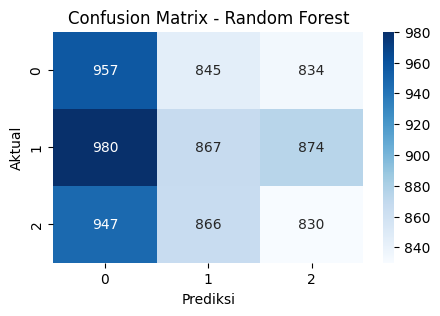


      EVALUASI: LOGISTIC REGRESSION
Akurasi: 32.38%

Classification Report:
               precision    recall  f1-score   support

        DDoS       0.33      0.78      0.46      2636
   Intrusion       0.32      0.13      0.18      2721
     Malware       0.32      0.07      0.11      2643

    accuracy                           0.32      8000
   macro avg       0.32      0.33      0.25      8000
weighted avg       0.32      0.32      0.25      8000



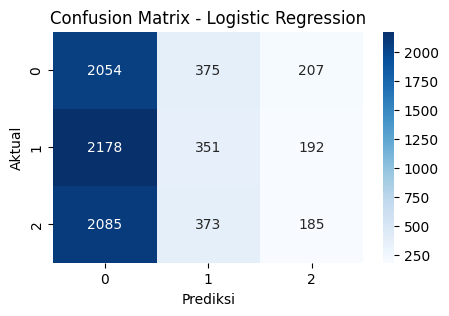


      EVALUASI: DECISION TREE
Akurasi: 33.17%

Classification Report:
               precision    recall  f1-score   support

        DDoS       0.33      0.34      0.34      2636
   Intrusion       0.33      0.32      0.33      2721
     Malware       0.33      0.33      0.33      2643

    accuracy                           0.33      8000
   macro avg       0.33      0.33      0.33      8000
weighted avg       0.33      0.33      0.33      8000



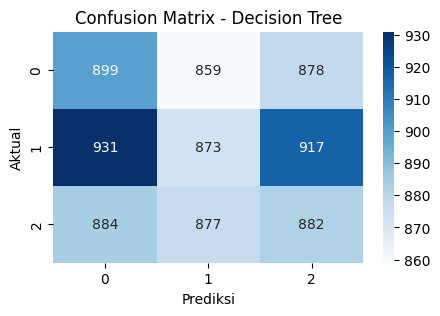

In [71]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Skala Data (Scaling)
num_cols = ['Source Port', 'Destination Port', 'Packet Length', 'Anomaly Scores']
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[num_cols])
X_test_scaled = scaler.transform(X_test[num_cols])

# 2. Definisi Model
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

# 3. Training & Evaluasi dalam satu perulangan (loop)
for name, model in models.items():
    # Latih model & buat prediksi
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    # Cetak Metrik Evaluasi
    print(f"\n{'='*40}\n      EVALUASI: {name.upper()}\n{'='*40}")
    print(f"Akurasi: {accuracy_score(y_test, y_pred):.2%}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    # Visualisasi Confusion Matrix
    plt.figure(figsize=(5, 3))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Prediksi')
    plt.ylabel('Aktual')
    plt.show()

In [72]:
import joblib
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Periksa apakah variabel yang dibutuhkan ada, jika tidak, muat ulang data
if 'rf_model' not in globals() or 'scaler' not in globals():
    print("🔄 Menginisialisasi ulang data dan melatih model...")

    # Load data jika df tidak ada
    if 'df' not in globals():
        file_path = r'C:/xampp/htdocs/cyber_security/static/cybersecurity_attacks.csv'
        
        df = pd.read_csv(file_path)

    # Menyiapkan data numerik
    numerical_cols = ['Source Port', 'Destination Port', 'Packet Length', 'Anomaly Scores']
    X = df[numerical_cols]
    y = df['Attack Type']

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    # Training
    rf_model = RandomForestClassifier(random_state=42)
    rf_model.fit(X_train_scaled, y_train)

# Simpan model dan scaler
joblib.dump(rf_model, 'model_ref.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("✅ Berhasil! 'model_ref.pkl' dan 'scaler.pkl' telah disimpan.")

✅ Berhasil! 'model_ref.pkl' dan 'scaler.pkl' telah disimpan.


In [74]:
pip install pickle

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement pickle (from versions: none)
ERROR: No matching distribution found for pickle


In [75]:
import pickle

# 1. Proses menyimpan model (ganti 'lr_model' dengan model pilihan Anda)
with open('model_ref.pkl', 'wb') as model_file:
    pickle.dump(lr_model, model_file)

# 2. Proses menyimpan scaler
with open('scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)

print("Selesai! Model dan Scaler langsung tersimpan di folder VS Code Anda.")

Selesai! Model dan Scaler langsung tersimpan di folder VS Code Anda.
